# 04 · Customer cohorts: do they come back?

Each acquisition campaign is a customer cohort. This notebook measures **durability**:
30/60/90-day repeat purchase, time to second order, monthly retention heatmap, and cumulative
contribution margin per customer over time — always comparing viral and non-viral cohorts.

In [1]:
import sys, warnings
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from metrics import customer_value, cohort_matrix
import viz; viz.setup()
pd.set_option("display.width", 180, "display.max_columns", 40)

c = pd.read_csv("../data/processed/campaigns_virality.csv", parse_dates=["campaign_date"])
cu = pd.read_csv("../data/processed/customers.csv", parse_dates=["acquisition_date", "first_purchase_date"])
o = pd.read_csv("../data/processed/orders.csv", parse_dates=["order_date"])

cv = customer_value(cu, o)
cv = cv.merge(c[["campaign_id", "campaign_type", "content_type", "creator_tier", "discount_pct", "virality_tier", "is_viral", "virality_score", "save_rate", "share_rate"]],
              left_on="acquisition_campaign", right_on="campaign_id")
cv.to_csv("../data/processed/customer_value.csv", index=False)
cv[["repeat_30d", "repeat_60d", "repeat_90d", "net_revenue_90d", "cm_90d", "days_to_second_order"]].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
repeat_30d,40947.0,0.19,0.39,0.00,0.00,0.00,0.00,1.00
repeat_60d,40947.0,0.35,0.48,0.00,0.00,0.00,1.00,1.00
repeat_90d,40947.0,0.40,0.49,0.00,0.00,0.00,1.00,1.00
net_revenue_90d,40947.0,157.66,147.74,11.33,58.92,97.17,207.95,1699.77
cm_90d,40947.0,57.15,71.57,-476.86,17.98,39.82,84.89,717.14
days_to_second_order,19295.0,49.08,44.06,2.00,20.00,38.00,60.00,355.00


## 1. Cohort table by campaign

Cohorts with fewer than 30 customers are excluded from rankings (noise), but kept in pooled numbers.

In [2]:
MIN_COHORT = 30
coh = cv.groupby(["acquisition_campaign", "virality_tier", "campaign_type", "content_type", "creator_tier", "discount_pct"]).agg(
    new_customers=("customer_id", "size"), repeat_30d=("repeat_30d", "mean"), repeat_60d=("repeat_60d", "mean"),
    repeat_90d=("repeat_90d", "mean"), cm_ltv_90d=("cm_90d", "mean"), median_days_to_2nd=("days_to_second_order", "median")).reset_index()
coh_big = coh[coh.new_customers >= MIN_COHORT]
print(f"{len(coh_big)} of {len(coh)} cohorts have ≥ {MIN_COHORT} customers")
coh_big.sort_values("cm_ltv_90d", ascending=False).head(10).round(3)

100 of 120 cohorts have ≥ 30 customers


,acquisition_campaign,virality_tier,campaign_type,content_type,creator_tier,discount_pct,new_customers,repeat_30d,repeat_60d,repeat_90d,cm_ltv_90d,median_days_to_2nd
52,IG_053,Standard,Influencer,Carousel,Mid,0,299,0.268,0.518,0.585,98.805,33.5
83,IG_084,Standard,UGC,Reel,Micro,0,50,0.280,0.520,0.540,96.085,31.0
33,IG_034,Standard,Organic,Reel,Brand,0,34,0.235,0.382,0.382,95.437,19.0
55,IG_056,Standard,Organic,Carousel,Brand,0,341,0.261,0.475,0.537,91.782,33.5
60,IG_061,Standard,Product Drop,Reel,Brand,0,70,0.271,0.486,0.586,89.749,33.0
70,IG_071,Standard,Influencer,Carousel,Micro,0,177,0.254,0.508,0.571,88.194,35.5
8,IG_009,Standard,Product Drop,Reel,Brand,0,325,0.265,0.486,0.545,87.604,33.0
16,IG_017,Standard,Product Drop,Live,Brand,0,126,0.278,0.468,0.532,87.241,33.5
81,IG_082,Standard,Organic,Reel,Brand,0,51,0.275,0.431,0.510,87.224,31.5
67,IG_068,Standard,UGC,Reel,Micro,0,453,0.274,0.514,0.596,85.730,34.0


In [3]:
coh_big.sort_values("cm_ltv_90d").head(10).round(3)

,acquisition_campaign,virality_tier,campaign_type,content_type,creator_tier,discount_pct,new_customers,repeat_30d,repeat_60d,repeat_90d,cm_ltv_90d,median_days_to_2nd
84,IG_085,Standard,Discount,Carousel,Brand,20,152,0.099,0.145,0.145,23.555,35.0
62,IG_063,Standard,Discount,Story,Brand,20,83,0.096,0.169,0.181,24.167,38.0
27,IG_028,Standard,Influencer,Carousel,Macro,10,196,0.092,0.189,0.219,25.796,50.0
99,IG_100,Standard,Discount,Story,Brand,30,239,0.088,0.176,0.188,25.878,42.0
50,IG_051,Standard,Discount,Story,Brand,25,150,0.073,0.133,0.153,26.193,57.5
114,IG_115,Standard,Discount,Reel,Brand,20,126,0.056,0.143,0.167,26.873,49.0
74,IG_075,Standard,Paid Amplification,Reel,Brand,10,138,0.109,0.203,0.217,27.310,39.0
86,IG_087,Standard,Discount,Story,Brand,20,102,0.078,0.186,0.245,27.621,53.0
72,IG_073,Viral,Paid Amplification,Carousel,Brand,15,556,0.072,0.156,0.174,28.239,48.0
47,IG_048,Viral,Discount,Reel,Brand,25,529,0.117,0.198,0.227,28.262,43.0


In [4]:
viral_tbl = coh[coh.virality_tier == "Viral"].sort_values("cm_ltv_90d", ascending=False)
viral_tbl.round(3)

,acquisition_campaign,virality_tier,campaign_type,content_type,creator_tier,discount_pct,new_customers,repeat_30d,repeat_60d,repeat_90d,cm_ltv_90d,median_days_to_2nd
7,IG_008,Viral,Organic,Reel,Brand,0,389,0.208,0.396,0.470,81.729,36.0
2,IG_003,Viral,Influencer,Reel,Macro,0,1059,0.161,0.288,0.327,69.127,39.0
37,IG_038,Viral,Paid Amplification,Carousel,Brand,15,4535,0.202,0.369,0.420,60.280,37.0
94,IG_095,Viral,Influencer,Reel,Macro,10,401,0.167,0.277,0.312,52.895,33.0
56,IG_057,Viral,Influencer,Reel,Mega,0,1291,0.147,0.281,0.322,42.134,38.0
9,IG_010,Viral,Paid Amplification,Reel,Brand,15,379,0.103,0.177,0.203,30.764,47.0
47,IG_048,Viral,Discount,Reel,Brand,25,529,0.117,0.198,0.227,28.262,43.0
72,IG_073,Viral,Paid Amplification,Carousel,Brand,15,556,0.072,0.156,0.174,28.239,48.0


Within the viral group, 90-day repeat ranges from under 20% to nearly 50% and 90-day CM-LTV spans roughly
3×. "Viral" is not a cohort quality; it is a distribution channel that carries very different customers.

## 2. Pooled comparison: viral vs non-viral customers

In [5]:
grp = cv.groupby("is_viral").agg(customers=("customer_id", "size"), repeat_30d=("repeat_30d", "mean"), repeat_60d=("repeat_60d", "mean"),
                                 repeat_90d=("repeat_90d", "mean"), avg_first_order=("first_order_value", "mean"),
                                 first_order_refund_rate=("first_order_refunded", "mean"), used_discount=("first_order_discount", lambda x: (x > 0).mean()),
                                 revenue_90d=("net_revenue_90d", "mean"), cm_ltv_90d=("cm_90d", "mean"), cm_ltv_90d_median=("cm_90d", "median"),
                                 median_days_to_2nd=("days_to_second_order", "median"))
grp.index = ["Non-viral", "Viral"]
grp.T.round(3)

,Non-viral,Viral
customers,31808.000,9139.000
repeat_30d,0.195,0.171
repeat_60d,0.365,0.313
repeat_90d,0.418,0.357
avg_first_order,87.591,91.198
first_order_refund_rate,0.108,0.110
used_discount,0.465,0.599
revenue_90d,159.702,150.535
cm_ltv_90d,57.965,54.304
cm_ltv_90d_median,40.725,35.830


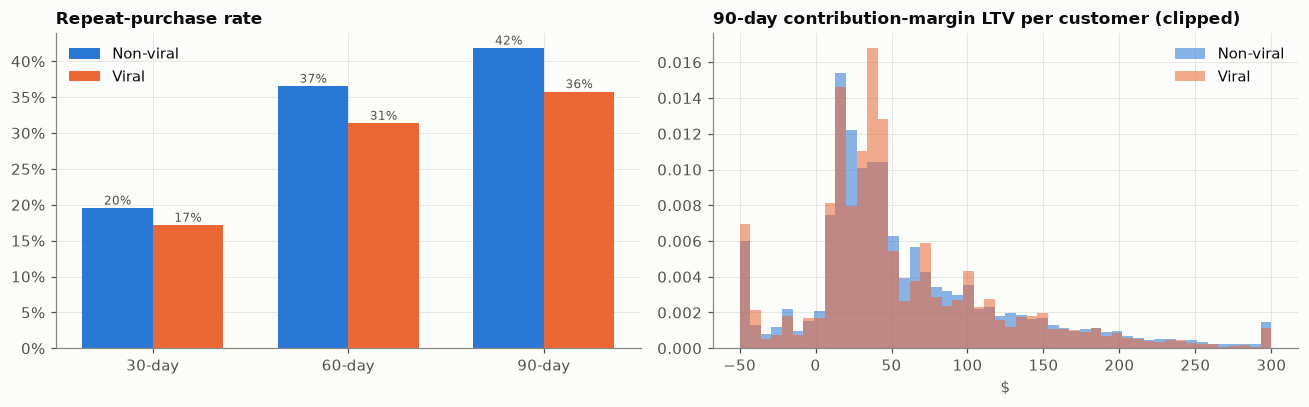

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
x = np.arange(3); w = 0.36
for i, (lbl, col) in enumerate([("Non-viral", viz.NONVIRAL), ("Viral", viz.VIRAL)]):
    vals = grp.loc[lbl, ["repeat_30d", "repeat_60d", "repeat_90d"]].values
    ax[0].bar(x + (i - 0.5) * w, vals, w, color=col, label=lbl)
    for xi, v in zip(x + (i - 0.5) * w, vals): ax[0].text(xi, v + 0.005, f"{v:.0%}", ha="center", fontsize=8, color=viz.INK2)
ax[0].set_xticks(x); ax[0].set_xticklabels(["30-day", "60-day", "90-day"]); ax[0].yaxis.set_major_formatter(FuncFormatter(viz.pct)); ax[0].set_title("Repeat-purchase rate"); ax[0].legend()
for lbl, col in [("Non-viral", viz.NONVIRAL), ("Viral", viz.VIRAL)]:
    d = cv[cv.is_viral == (lbl == "Viral")].cm_90d.clip(-50, 300)
    ax[1].hist(d, bins=50, density=True, alpha=0.55, color=col, label=lbl)
ax[1].set_title("90-day contribution-margin LTV per customer (clipped)"); ax[1].set_xlabel("$"); ax[1].legend()
plt.tight_layout(); plt.savefig("../images/04_viral_vs_nonviral.png"); plt.show()

## 3. Time to second purchase — a "survival" view

Share of each group that has placed a second order by day *t*.

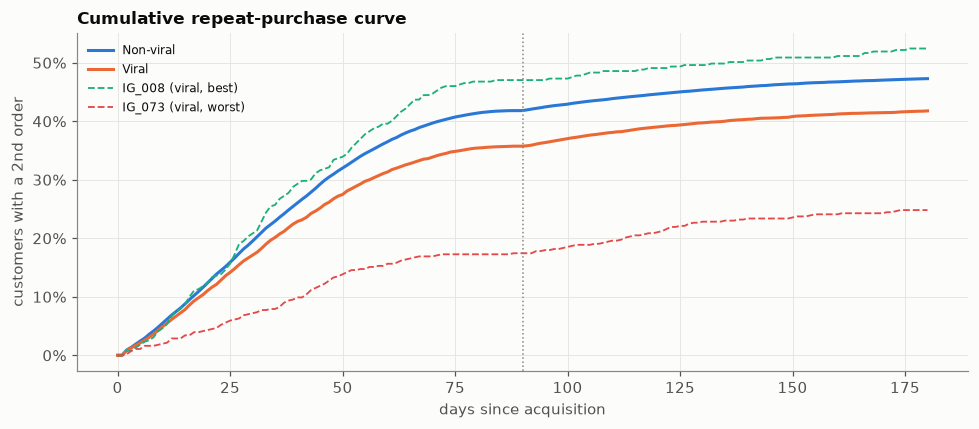

In [7]:
def repeat_curve(d, horizon=180):
    t = np.arange(0, horizon + 1)
    dts = d.days_to_second_order.dropna().values
    return t, np.array([(dts <= x).mean() * len(dts) / len(d) for x in t])

fig, ax = plt.subplots(figsize=(9, 4))
for lbl, col in [("Non-viral", viz.NONVIRAL), ("Viral", viz.VIRAL)]:
    t, y = repeat_curve(cv[cv.is_viral == (lbl == "Viral")])
    ax.plot(t, y, color=col, label=lbl)
for cid, col in zip(viral_tbl.acquisition_campaign.iloc[[0, -1]], [viz.SERIES[2], viz.SERIES[7]]):
    t, y = repeat_curve(cv[cv.acquisition_campaign == cid])
    ax.plot(t, y, color=col, linewidth=1.2, linestyle="--", label=f"{cid} (viral, {'best' if col == viz.SERIES[2] else 'worst'})")
ax.axvline(90, color=viz.MUTED, linestyle=":", linewidth=1)
ax.yaxis.set_major_formatter(FuncFormatter(viz.pct)); ax.set_xlabel("days since acquisition"); ax.set_ylabel("customers with a 2nd order")
ax.set_title("Cumulative repeat-purchase curve"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("../images/04_repeat_curve.png"); plt.show()

## 4. Monthly cohort retention heatmap

Share of each acquisition-month cohort with an order in month *k* after acquisition (k = 0 is the
acquisition month). Cells beyond the observation window are blank.

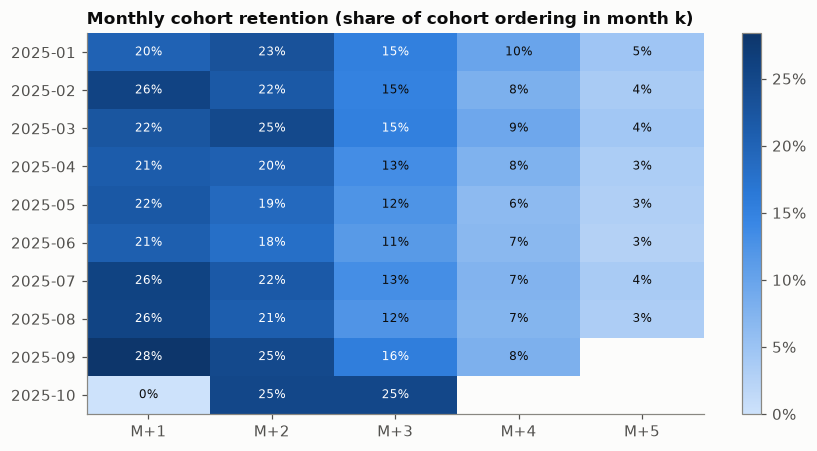

In [8]:
mat = cohort_matrix(cu, o, periods=5)
obs_end = o.order_date.max().to_period("M")
for k in mat.columns:
    for coh_m in mat.index:
        if coh_m + k > obs_end:
            mat.loc[coh_m, k] = np.nan
fig, ax = plt.subplots(figsize=(8, 4.2))
im = ax.imshow(mat.iloc[:, 1:].values, cmap=viz.blues_cmap(), aspect="auto", vmin=0, vmax=np.nanmax(mat.iloc[:, 1:].values))
ax.set_xticks(range(mat.shape[1] - 1)); ax.set_xticklabels([f"M+{k}" for k in mat.columns[1:]])
ax.set_yticks(range(len(mat))); ax.set_yticklabels([str(i) for i in mat.index]); ax.grid(False)
for i in range(len(mat)):
    for j in range(1, mat.shape[1]):
        v = mat.iloc[i, j]
        if not np.isnan(v):
            ax.text(j - 1, i, f"{v:.0%}", ha="center", va="center", fontsize=8, color=viz.INK if v < 0.15 else "white")
ax.set_title("Monthly cohort retention (share of cohort ordering in month k)"); plt.colorbar(im, ax=ax, format=FuncFormatter(viz.pct))
plt.tight_layout(); plt.savefig("../images/04_cohort_heatmap.png"); plt.show()

In [9]:
mat_v = {}
for lbl in ["Non-viral", "Viral"]:
    sub = cu[cu.acquisition_campaign.isin(c[c.is_viral == (lbl == "Viral")].campaign_id)]
    m = cohort_matrix(sub, o[o.customer_id.isin(sub.customer_id)], periods=3)
    mat_v[lbl] = m.iloc[:, 1:].mean()
pd.DataFrame(mat_v).rename(index=lambda k: f"M+{k}").round(3)

,Non-viral,Viral
k,,
M+1,0.218,0.178
M+2,0.229,0.153
M+3,0.154,0.101


## 5. Cumulative contribution margin per customer

The economic version of the retention curve: how much margin a customer has generated by day *t*.

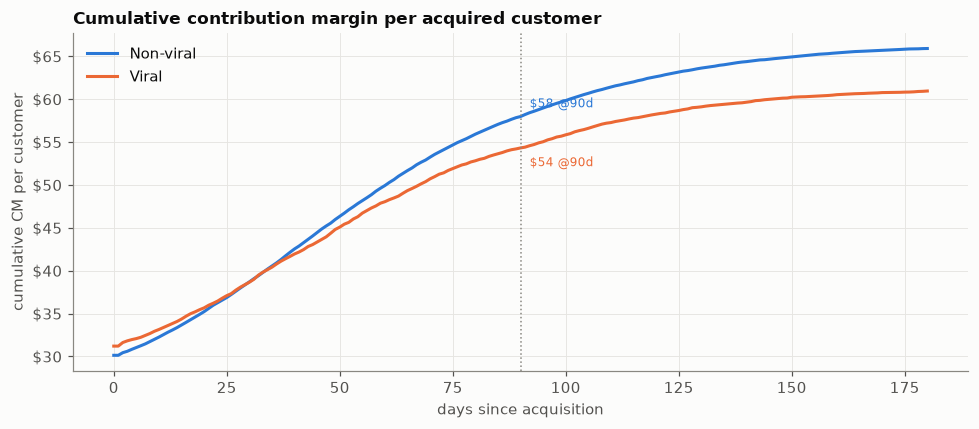

In [10]:
oc = o.merge(cv[["customer_id", "is_viral", "acquisition_date"]], on="customer_id")
oc["d"] = (oc.order_date - oc.acquisition_date).dt.days
fig, ax = plt.subplots(figsize=(9, 4))
for lbl, col in [("Non-viral", viz.NONVIRAL), ("Viral", viz.VIRAL)]:
    d = oc[oc.is_viral == (lbl == "Viral")]
    n = (cv.is_viral == (lbl == "Viral")).sum()
    cum = d.groupby("d").contribution_margin.sum().reindex(range(0, 181), fill_value=0).cumsum() / n
    ax.plot(cum.index, cum.values, color=col, label=lbl)
    ax.annotate(f"${cum[90]:.0f} @90d", (90, cum[90]), xytext=(6, -12 if lbl == "Viral" else 6), textcoords="offset points", fontsize=8, color=col)
ax.axvline(90, color=viz.MUTED, linestyle=":", linewidth=1)
ax.yaxis.set_major_formatter(FuncFormatter(viz.money)); ax.set_xlabel("days since acquisition"); ax.set_ylabel("cumulative CM per customer")
ax.set_title("Cumulative contribution margin per acquired customer"); ax.legend()
plt.tight_layout(); plt.savefig("../images/04_cumulative_cm.png"); plt.show()

## 6. What drives durability? A first look at observable factors

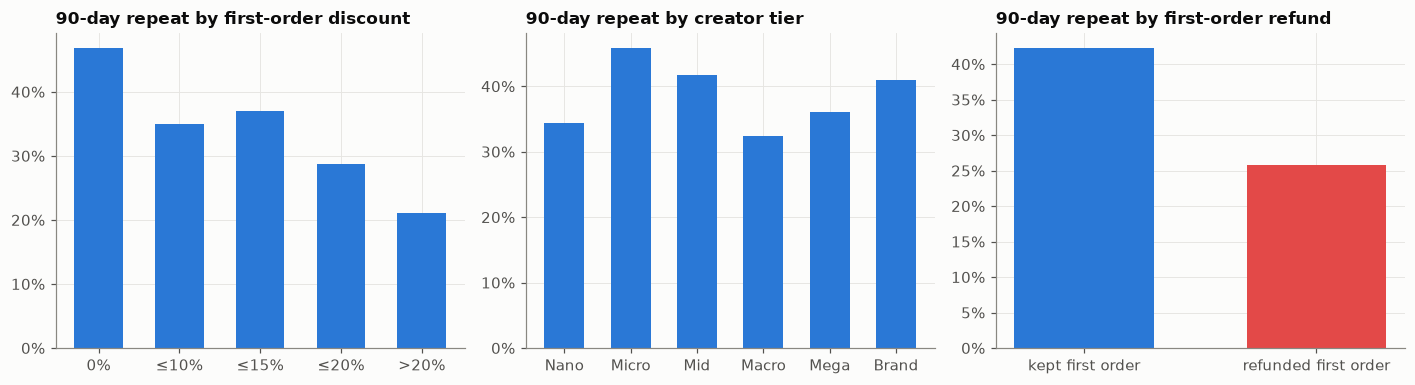

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
cv["discount_band"] = pd.cut(cv.first_order_discount_pct, [-1, 0, 10, 15, 20, 30], labels=["0%", "≤10%", "≤15%", "≤20%", ">20%"])
d = cv.groupby("discount_band").repeat_90d.mean()
ax[0].bar(d.index.astype(str), d.values, color=viz.SERIES[0], width=0.6); ax[0].yaxis.set_major_formatter(FuncFormatter(viz.pct)); ax[0].set_title("90-day repeat by first-order discount")
d = cv.groupby("creator_tier").repeat_90d.mean().reindex(["Nano", "Micro", "Mid", "Macro", "Mega", "Brand"])
ax[1].bar(d.index, d.values, color=viz.SERIES[0], width=0.6); ax[1].yaxis.set_major_formatter(FuncFormatter(viz.pct)); ax[1].set_title("90-day repeat by creator tier")
d = cv.groupby("first_order_refunded").repeat_90d.mean()
ax[2].bar(["kept first order", "refunded first order"], d.values, color=[viz.SERIES[0], viz.SERIES[7]], width=0.6); ax[2].yaxis.set_major_formatter(FuncFormatter(viz.pct)); ax[2].set_title("90-day repeat by first-order refund")
plt.tight_layout(); plt.savefig("../images/04_durability_drivers.png"); plt.show()

**Takeaways.**
- Pooled, viral-acquired customers repeat less and generate less 90-day contribution margin than non-viral
  customers, and they take longer to come back.
- But the spread *inside* the viral group is larger than the gap *between* groups: 90-day CM-LTV runs from
  under $30 to over $80 across the eight viral cohorts, and the best of them ranks among the top cohorts in
  the whole portfolio.
- Discount depth at the first order, creator tier and a refunded first order are all visibly associated with
  durability; these are observable, controllable levers. Notebook 06 tests them formally.